## Dot plot of NK, adaptive and ILC markers in combined PBMC data

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
from matplotlib import rcParams
import numpy as np
import seaborn as sns

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 600

In [ ]:
# load combined PBMC data

In [3]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/PBMC_combined_Malm_ding_Tcell_filtered/PBMC_combined_malm_ding_Tcellfitered_SI_pciml_tciml_Donor.h5ad")

In [ ]:
# copying raw gene counts to counts layer and normalinzing the counts

In [4]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [5]:
adata

AnnData object with n_obs × n_vars = 66309 × 14337
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'species', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.1', 'seurat_clusters', 'unfilt_clusters', 'RNA_snn_res.0.8', 'RNA_snn_res.0.4', 'RNA_snn_res.0.6', 'Renamed', 'predicted.spca.NK_annot.ref.score', 'predicted.spca.NK_annot.ref', 'predicted.spca.main.NK.ref.score', 'predicted.spca.main.NK.ref', 'predicted.spca.major.ref.score', 'predicted.spca.major.ref', 'predicted.spca.NK_annot.score', 'predicted.spca.NK_annot', 'predicted.spca.main.NK.score', 'predicted.spca.main.NK', 'predicted.spca.major.score', 'predicted.spca.major', 'predicted.spca.harmony.score', 'predicted.spca.harmony', 'predicted.spca.main.score', 'predicted.spca.main', 'batch', 'celltype.l2', 'dataset_name', '_scvi_labels', '_scvi_batch', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'CD56brightBRFprob', 'CD56dimBRFprob', 'eML1BRFprob', 'eML2BRFprob'

In [6]:
adata.obs["classification"].value_counts()

classification
CD56dim          54323
CD56bright        6775
ML1               2301
ML_transition     1221
unclassified      1015
ML2                674
Name: count, dtype: int64

In [58]:
# removing unclassified cells

In [7]:
adata_v2 = adata[adata.obs['classification'] != 'unclassified', :]
adata_v2.obs['group'] = adata_v2.obs['classification'].replace({ 'ML1': 'iML', 'ML2':'iML', 'ML_transition':'iML'})

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_1083/444949260.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_v2.obs['group'] = adata_v2.obs['classification'].replace({ 'ML1': 'iML', 'ML2':'iML', 'ML_transition':'iML'})
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_1083/444949260.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_v2.obs['group'] = adata_v2.obs['classification'].replace({ 'ML1': 'iML', 'ML2':'iML', 'ML_transition':'iML'})


In [8]:
adata_v2

AnnData object with n_obs × n_vars = 65294 × 14337
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'species', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.1', 'seurat_clusters', 'unfilt_clusters', 'RNA_snn_res.0.8', 'RNA_snn_res.0.4', 'RNA_snn_res.0.6', 'Renamed', 'predicted.spca.NK_annot.ref.score', 'predicted.spca.NK_annot.ref', 'predicted.spca.main.NK.ref.score', 'predicted.spca.main.NK.ref', 'predicted.spca.major.ref.score', 'predicted.spca.major.ref', 'predicted.spca.NK_annot.score', 'predicted.spca.NK_annot', 'predicted.spca.main.NK.score', 'predicted.spca.main.NK', 'predicted.spca.major.score', 'predicted.spca.major', 'predicted.spca.harmony.score', 'predicted.spca.harmony', 'predicted.spca.main.score', 'predicted.spca.main', 'batch', 'celltype.l2', 'dataset_name', '_scvi_labels', '_scvi_batch', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'CD56brightBRFprob', 'CD56dimBRFprob', 'eML1BRFprob', 'eML2BRFprob'

In [9]:
adata_v2.obs["group"].value_counts()

group
CD56dim       54323
CD56bright     6775
iML            4196
Name: count, dtype: int64

In [10]:
sc.pp.scale(adata_v2, zero_center=True, max_value=None)

In [ ]:
# Plotting Memory like NK cell markers

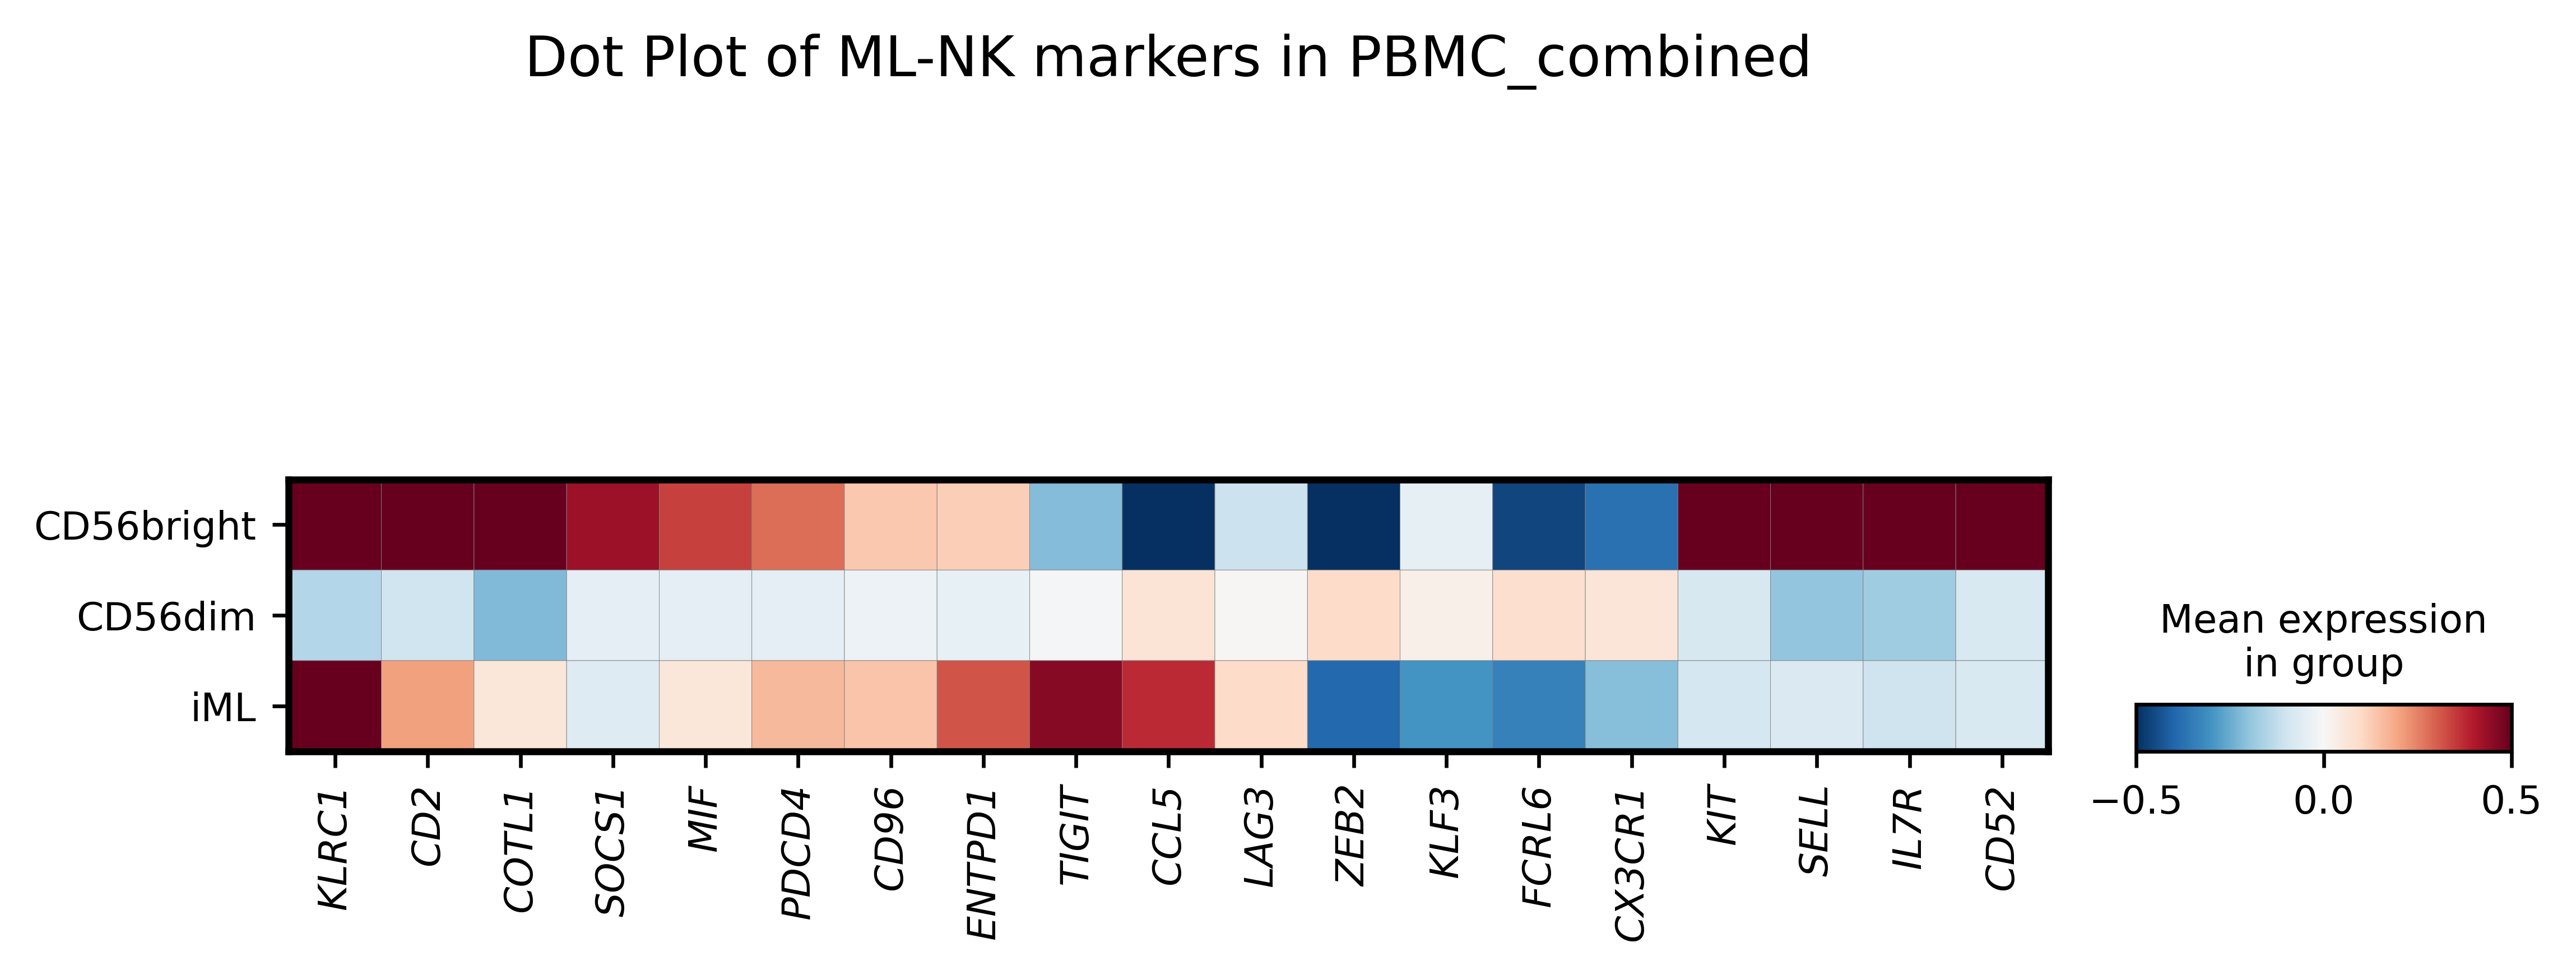

In [16]:
genes = ["KLRC1", "CD2", "COTL1", "SOCS1", "MIF", "PDCD4", "CD96", "ENTPD1", "TIGIT", "CCL5", "LAG3", 
           "ZEB2", "KLF3", "FCRL6", "CX3CR1",   "KIT", "SELL", "IL7R", "CD52"]

# Plot the matrixplot and get the figure object
mp = sc.pl.matrixplot(
    adata_v2,
    var_names=genes,
    groupby='group',
    use_raw=False, 
    cmap='RdBu_r',
    vmin=-0.5, vmax=0.5, 
    swap_axes=False,
    return_fig=True,
    show=False,
    title='Dot Plot of ML-NK markers in PBMC_combined'
)

# Italicize gene names
ax = mp.get_axes()  # Main heatmap axes
for label in ax['mainplot_ax'].get_xticklabels():
    label.set_fontstyle('italic')

plt.show()


In [73]:
# ILC and Tissue resident markers

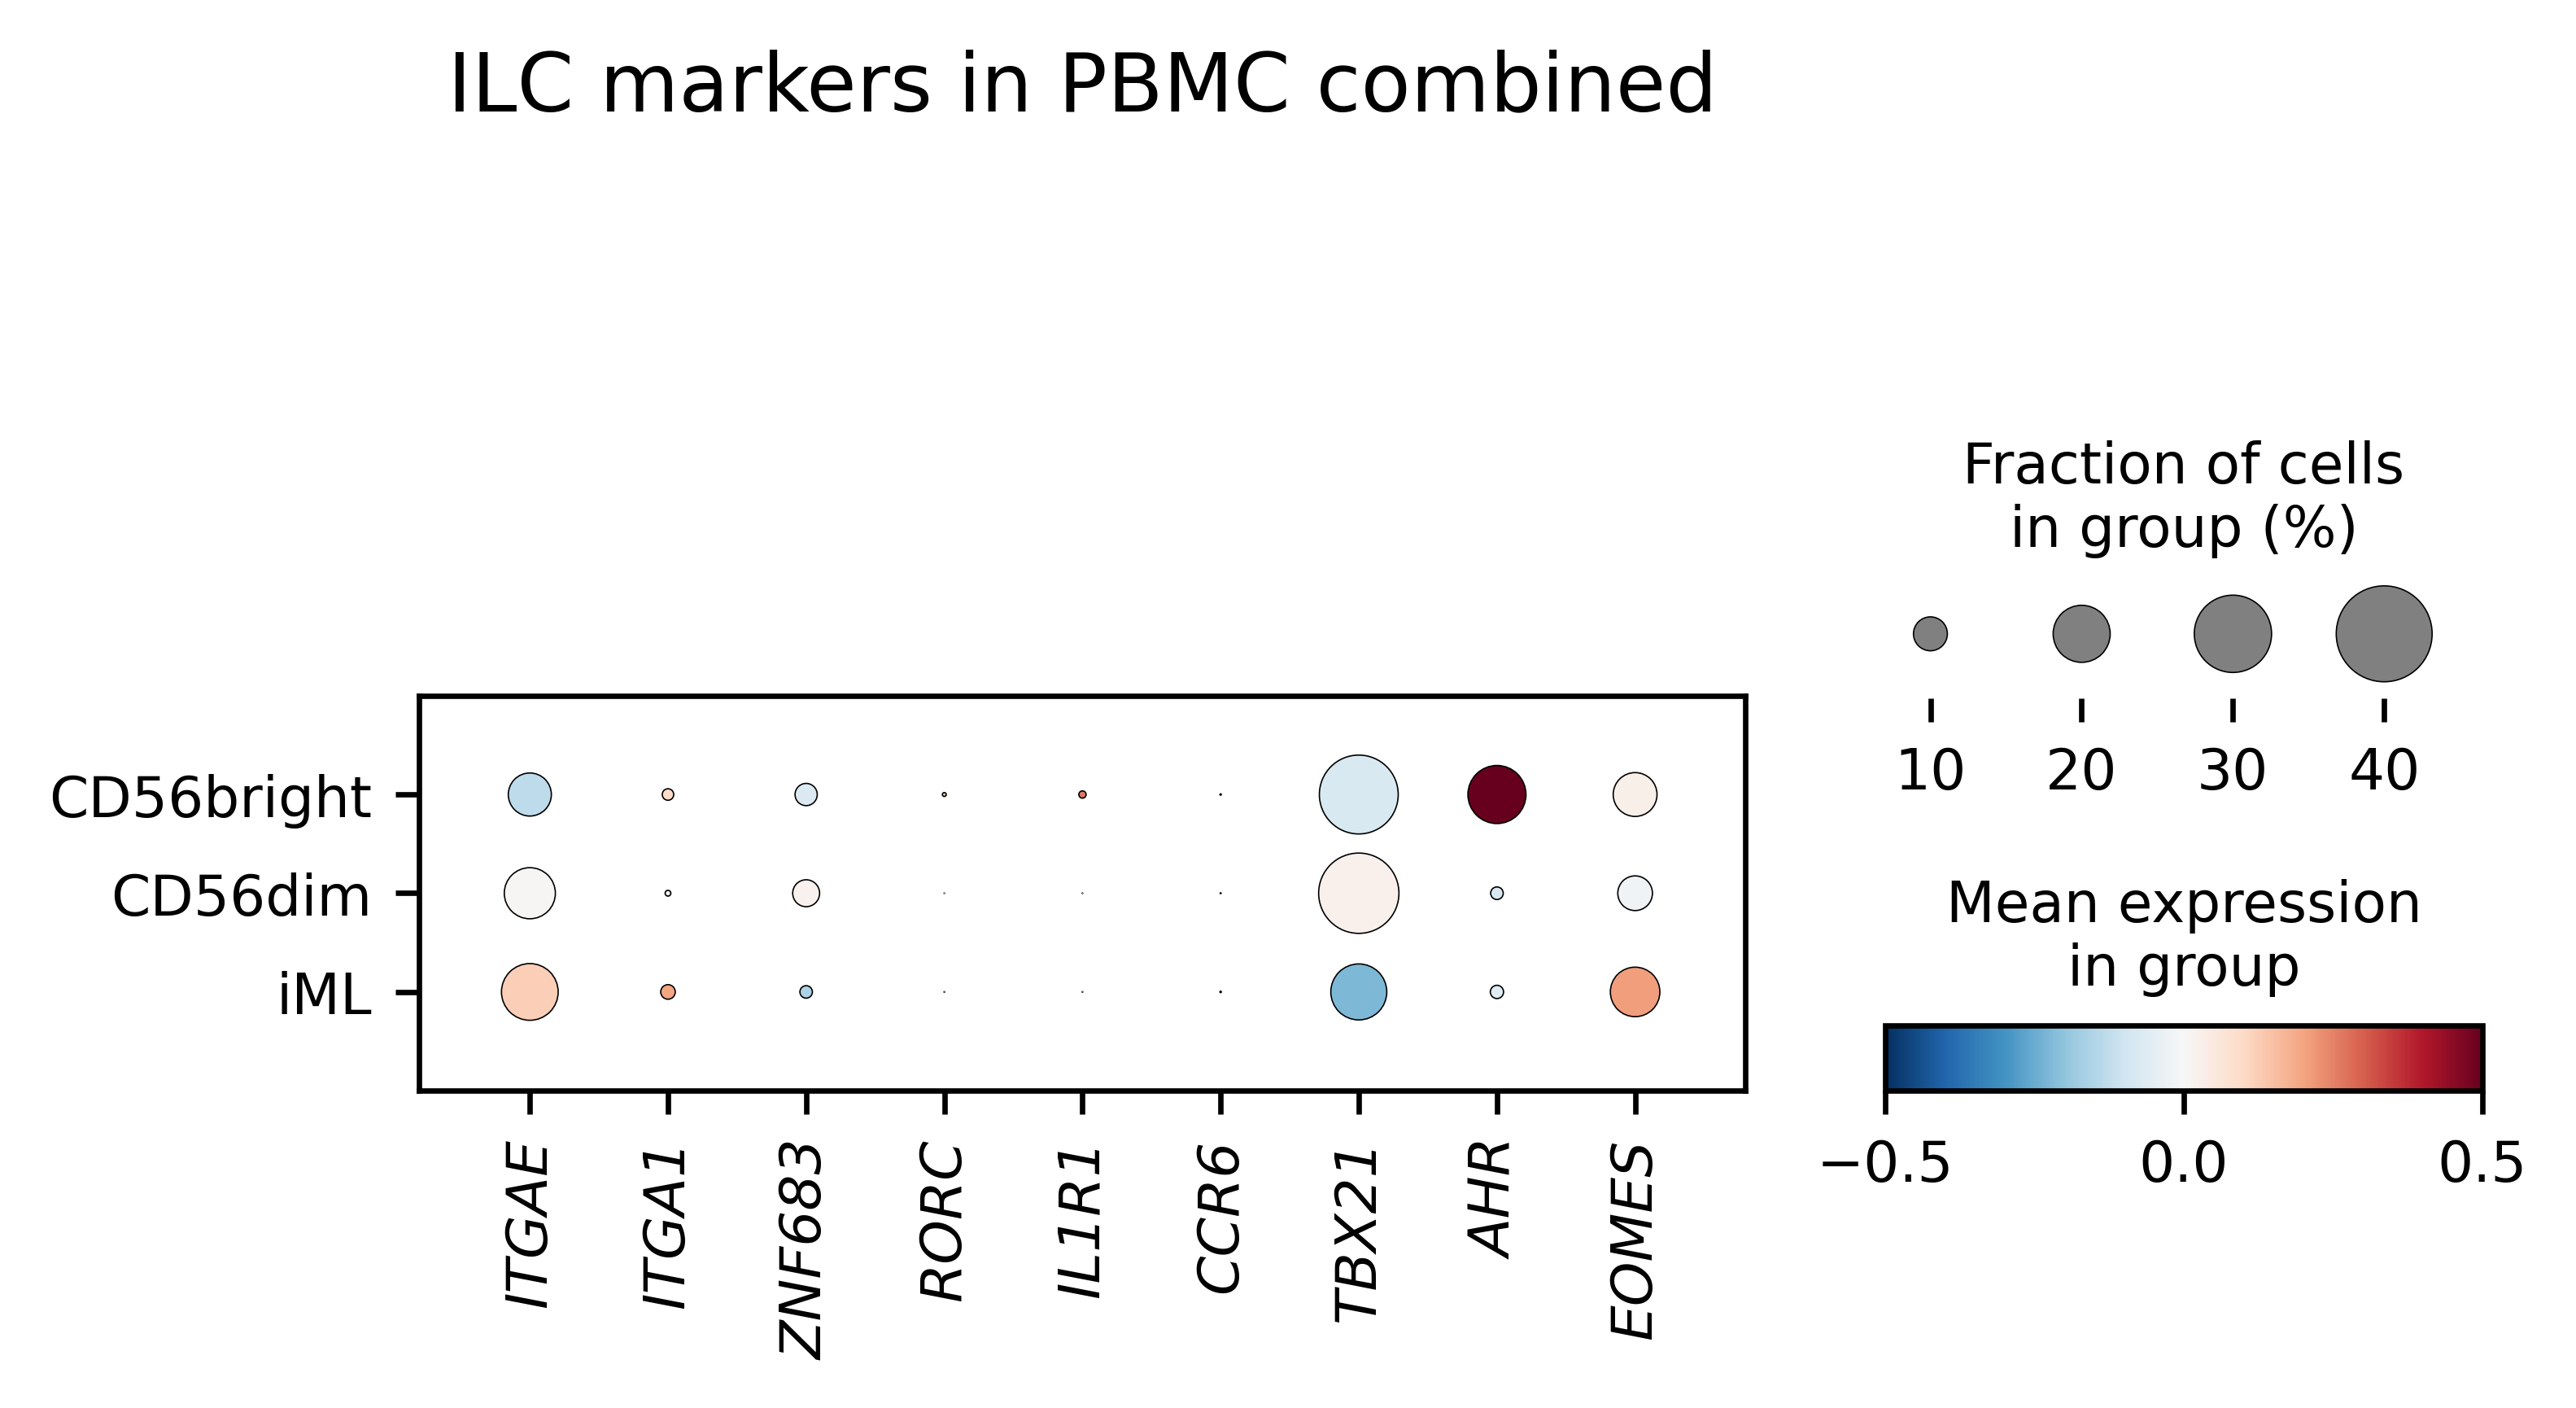

In [75]:
genes = [ "ITGAE", "ITGA1", "ZNF683", "RORC", "IL1R1", "CCR6","TBX21", "AHR", "EOMES"]

# Generate a combined dot plot and modify it
dp = sc.pl.dotplot(adata_v2, var_names=genes, groupby='group',  use_raw=False, 
                    cmap='RdBu_r', title="ILC markers in PBMC combined",
                    vmin=-0.5, vmax=0.5,return_fig=True, show=False)

# Make gene names italic
ax = dp.get_axes()
for label in ax['mainplot_ax'].get_xticklabels():
    label.set_fontstyle('italic')
plt.subplots_adjust(right=1)  
plt.show()

In [76]:
# Pydeseq2-PBMC combined iML vs CD56dim or CD56bright

In [91]:
genes_v3 =[      
    #CD56dim
    "FGFBP2","LYAR", "KLF2", "SPON2", "ZEB2",
     "CCL4", "LITAF", "PRF1", 
    "TNFRSF18", "CXCR3", "CD44", "LINC00996",
     #CD56bright
     "SELL", "GPR183", "IL7R",
    "KLRC2", "FOS", "TCF7", "RUNX3" , "CAPG",
     "S1PR5", "LBH", "TIGIT",
     "ALOX5AP", "CST7","CCL5", "PYHIN1",
    "GZMA", "KLRB1", "CD247","GZMB"
]

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_16580/315795675.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expr_data.groupby('group')[genes_v3]


Genes passing 20% expression threshold - CD56dim, CD56bright or iML): [np.str_('FGFBP2'), np.str_('LYAR'), np.str_('KLF2'), np.str_('SPON2'), np.str_('ZEB2'), np.str_('CCL4'), np.str_('LITAF'), np.str_('PRF1'), np.str_('TNFRSF18'), np.str_('CXCR3'), np.str_('CD44'), np.str_('LINC00996'), np.str_('SELL'), np.str_('GPR183'), np.str_('IL7R'), np.str_('KLRC2'), np.str_('FOS'), np.str_('TCF7'), np.str_('RUNX3'), np.str_('CAPG'), np.str_('S1PR5'), np.str_('LBH'), np.str_('TIGIT'), np.str_('ALOX5AP'), np.str_('CST7'), np.str_('CCL5'), np.str_('PYHIN1'), np.str_('GZMA'), np.str_('KLRB1'), np.str_('CD247'), np.str_('GZMB')]


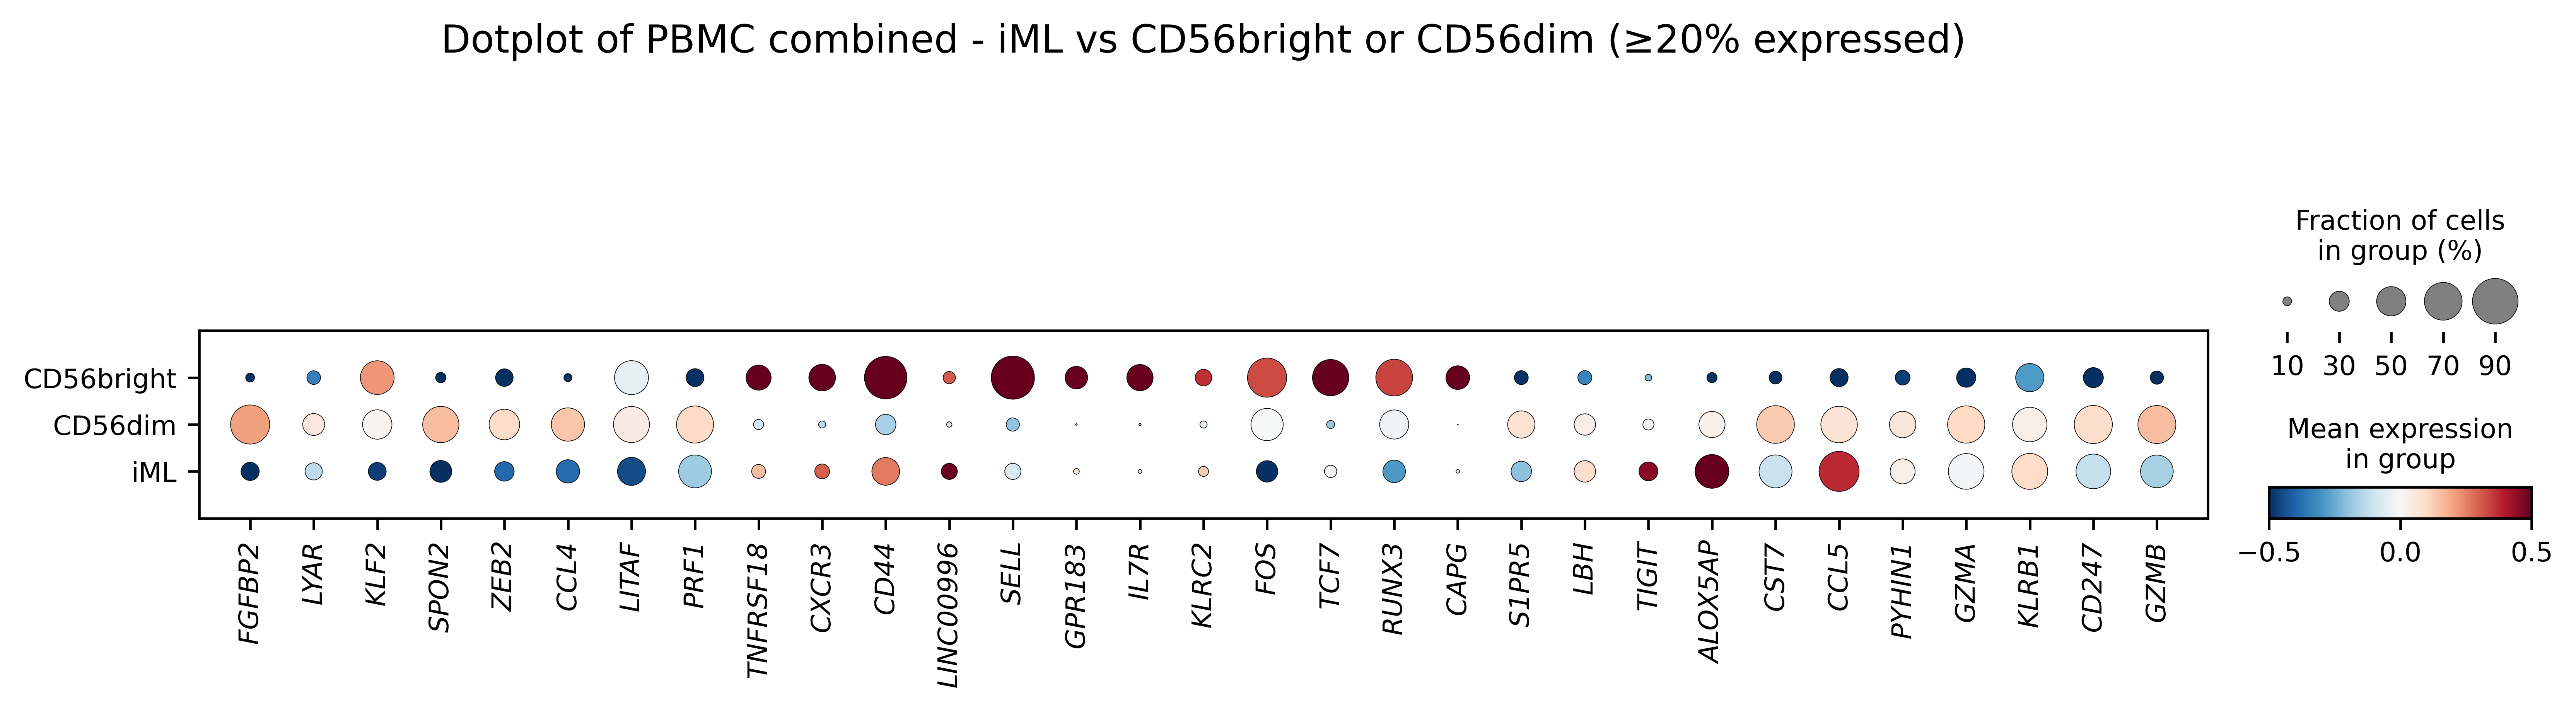

In [92]:
# Compute fraction of cells expressing each gene per group
expr_data = sc.get.obs_df(adata_v2, keys=['group'] + genes_v3)

expr_frac = (
    expr_data.groupby('group')[genes_v3]
    .apply(lambda x: (x > 0).sum() / x.shape[0]))

# Define which groups to apply the threshold to
groups_of_interest = ['CD56bright', 'iML', 'CD56dim']

# Keep genes expressed in >=20% of cells in at least one of the selected groups
keep_genes = expr_frac.loc[groups_of_interest].columns[
    (expr_frac.loc[groups_of_interest] >= 0.2).any(axis=0)
].tolist()

print("Genes passing 20% expression threshold - CD56dim, CD56bright or iML):", keep_genes)

# --- DOTPLOT ---
dp = sc.pl.dotplot(
    adata_v2,
    var_names=keep_genes,
    groupby='group',
    use_raw=False,
    color_map='RdBu_r',  # color scale
    title='Dotplot of PBMC combined - iML vs CD56bright or CD56dim (≥20% expressed)',
    return_fig=True,
    show=False, vmax=0.5, vmin=-0.5
)

# Italicize gene names
ax = dp.get_axes()
for label in ax['mainplot_ax'].get_xticklabels():
    label.set_fontstyle('italic')

plt.show()
